In [21]:
import numpy as np
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt


In [22]:
X = np.array([
    [25, 2, 1],
    [45, 1, 0],
    [60, 2, 1],
    [30, 0, 0],
    [50, 1, 1],
    [22, 0, 0],
    [65, 2, 0],
    [40, 1, 1],
    [55, 0, 1],
    [35, 2, 0]
])

drug = np.array(['DrugA', 'DrugB', 'DrugC', 'DrugA', 'DrugB',
                  'DrugA', 'DrugC', 'DrugB', 'DrugC', 'DrugA'])

In [23]:
model = DecisionTreeClassifier(criterion='entropy',max_depth=3,random_state=42)
model.fit(X,drug)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'entropy'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
patient = [[48,1,0]]
pred = model.predict(patient)
print("Predicted Drug:",pred[0])

Predicted Drug: DrugB


[Text(0.4, 0.8333333333333334, 'Age <= 37.5\nentropy = 1.571\nsamples = 10\nvalue = [4, 3, 3]\nclass = DrugA'),
 Text(0.2, 0.5, 'entropy = 0.0\nsamples = 4\nvalue = [4, 0, 0]\nclass = DrugA'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'Age <= 52.5\nentropy = 1.0\nsamples = 6\nvalue = [0, 3, 3]\nclass = DrugB'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'entropy = 0.0\nsamples = 3\nvalue = [0, 3, 0]\nclass = DrugB'),
 Text(0.8, 0.16666666666666666, 'entropy = 0.0\nsamples = 3\nvalue = [0, 0, 3]\nclass = DrugC')]

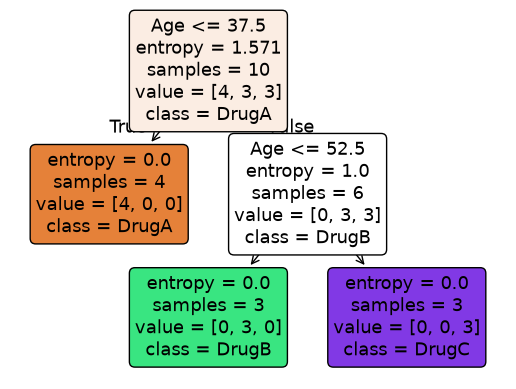

In [33]:
plt.Figure(figsize=(17,15))
plot_tree(model, feature_names=['Age','BP','Cholestrol'],class_names=model.classes_,filled=True,rounded=True)

In [26]:
importance = model.feature_importances_
features = ['Age', 'Blood Pressure', 'Cholesterol']

for feat, imp in zip(features, importance):
    print(f"{feat}: {imp:.3f}")

Age: 1.000
Blood Pressure: 0.000
Cholesterol: 0.000


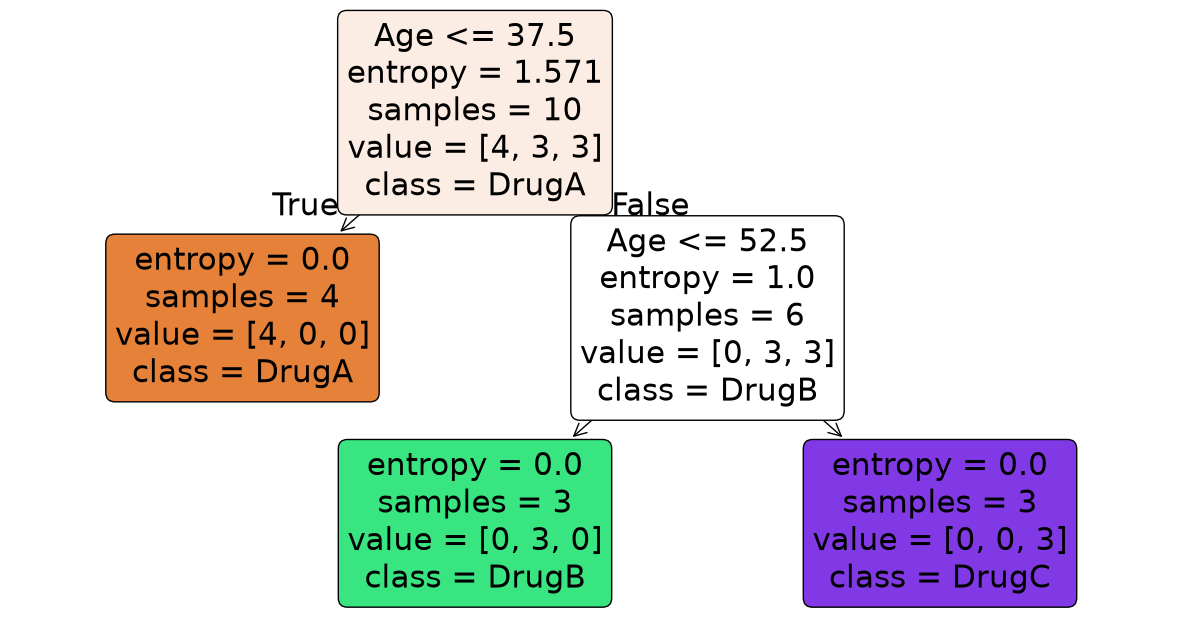

In [27]:
overfit_model = DecisionTreeClassifier(criterion='entropy')  # max_depth nahi diya
overfit_model.fit(X, drug)

plt.figure(figsize=(15, 8))
plot_tree(overfit_model, feature_names=['Age', 'Blood Pressure', 'Cholesterol'],
          class_names=overfit_model.classes_, filled=True, rounded=True)
plt.show()

In [28]:
predictions_all = model.predict(X)
accuracy = np.mean(predictions_all == drug)
print("Accuracy:", accuracy)

Accuracy: 1.0
